In [36]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')
train_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.csv')
test_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.csv')
train_h5_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.h5')
test_h5_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.h5')
sys.path.append(base_dir)

from src.tools.window_shifter import WindowShifter
from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

In [37]:
import pandas as pd
import numpy as np
import os

train_npy_dir = train_h5_dir.replace('.h5', '.npy')
test_npy_dir = test_h5_dir.replace('.h5', '.npy')

if not os.path.exists(train_npy_dir):
    print("Đang chuyển đổi tập Train sang Numpy...")
    df_train = pd.read_hdf(train_h5_dir, key='train_house2')
    np.save(train_npy_dir, df_train.values.astype(np.float32))
    del df_train
    print("Xong tập Train!")

if not os.path.exists(test_npy_dir):
    print("Đang chuyển đổi tập Test sang Numpy...")
    df_test = pd.read_hdf(test_h5_dir, key='test_house2')
    np.save(test_npy_dir, df_test.values.astype(np.float32))
    del df_test
    print("Xong tập Test!")

print("File .npy đã sẵn sàng để train!")

File .npy đã sẵn sàng để train!


In [38]:
import numpy as np
import torch
from torch.utils.data import Dataset

class NILMDataset(Dataset):
    def __init__(self, data_dir, key=None, transform=None):
        self.transform = transform
        npy_dir = data_dir.replace('.h5', '.npy')
        self.data_matrix = np.load(npy_dir, mmap_mode='r')
        self.total_lines = self.data_matrix.shape[0]

    def __len__(self):
        return self.total_lines

    def __getitem__(self, idx):
        row = self.data_matrix[idx] 
        data = torch.tensor(row[:-9], dtype=torch.float32)
        label = torch.tensor(row[-9:], dtype=torch.float32)
        if self.transform:
            data = self.transform(data)
        data = data.unsqueeze(dim = 0)
        return data, label


In [39]:
with pd.HDFStore(train_h5_dir, mode = 'r') as store:
            sample = store.select(key = 'train_house2', start = 0, stop = 1)
data = sample.iloc[:,:-9].values.astype(np.float32)
label = sample.iloc[:,-9:].values.astype(np.float32)
output = torch.tensor(data, requires_grad = False)

In [40]:
output.permute(1,0)

tensor([[ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 88.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        

In [41]:
train_dataset = NILMDataset(train_h5_dir, 'train_house2')
test_dataset = NILMDataset(test_h5_dir, 'test_house2')

In [42]:
batch_size = 256
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False, num_workers = 0)

In [43]:
if __name__ == '__main__':
    test = next(iter(train_loader))

In [44]:
test[0].shape

torch.Size([256, 1, 300])

In [45]:
test[1].shape

torch.Size([256, 9])

In [46]:
len(train_loader)

10287

# Architecture: Encoder ###
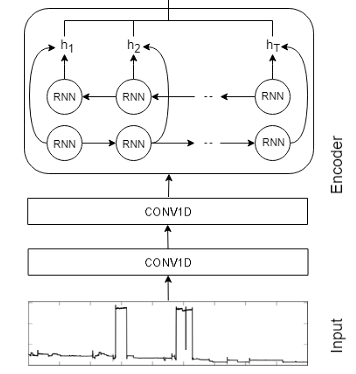

# Attention + Decoder ###
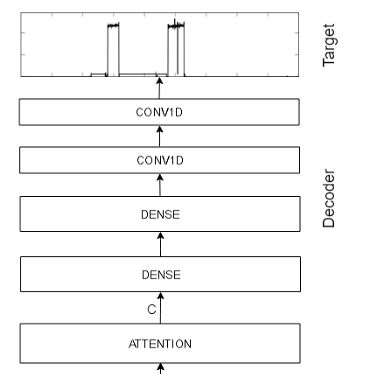

# Chú ý ###
Trong paper đang là kiến trúc s2s nhưng kiến trúc này có vấn đề chính là nó hoạt động giống nlp, yêu cầu 1 chuỗi đầu vào và đưa ra 1 chuỗi đầu ra vấn đề là nếu như có 2 chuỗi overlap với nhau thì kết quả công suất dự đoán của đoạn overlap chưa chắc giống nhau?. Vì thế nên biến đổi kiến trúc của phần decoder đi bằng cách bỏ đi 2 cái conv1d. Sau khi lấy được c từ lớp attention chỉ cần thêm 1 hoặc 2 lớp dense để lấy ra 1 output duy nhất

In [47]:
in_channels = 1
conv_filters = 32
kernel_size = 3
enc_conv1 = nn.Conv1d(in_channels, conv_filters, kernel_size, padding=kernel_size//2)
        # 3) Conv1D (F filters, linear)
enc_conv2 = nn.Conv1d(conv_filters, conv_filters, kernel_size, padding=kernel_size//2)
enc_conv1(test[0]).shape

torch.Size([256, 32, 300])

# Chú ý ###
Vì lstm yêu cầu đầu vào theo các bước thời gian nên cần shape là batch, length, channels, tưởng tượng mỗi bước thời gian là 1 điểm dữ liệu (có tất cả channels lớp, 1 điểm dữ liệu là xiên tất cả channels lớp đó)

# Cấu tạo của Attention ###
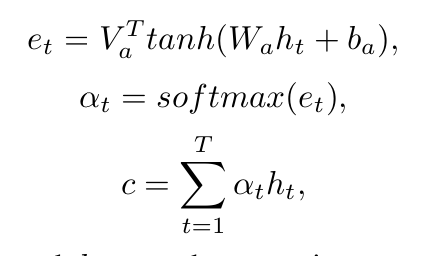

In [48]:
class S2PwAModel(nn.Module):
    def __init__(self, window_length = 300, in_channels = 1, filter_nums = 32, kernel_size = 3, hidden_dim = 64):
        super().__init__()
        self.window_length = window_length

        # Encoder
        self.conv1 = nn.Conv1d(in_channels, out_channels = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels  = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.bilstm = nn.LSTM(input_size = 32, hidden_size = hidden_dim, batch_first = True, bidirectional = True)
        bilstm_out_dim = hidden_dim * 2 # concat 2 vector của hidden state theo 2 chiều

        # Attention
        self.v_a = nn.Linear(hidden_dim, 1, bias = False)
        self.att_dense = nn.Linear(bilstm_out_dim, hidden_dim)
        self.att_softmax = nn.Softmax(dim = 1)
        
        # thay đổi kiến trúc cũ
        # đầu ra của attention là batch, bilstm_out_dim
        self.fc1 = nn.Linear(bilstm_out_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
    
    def forward(self, x):
        # x sau khi lấy ra từ dataloader đang có dạng batch, channels, length
        x = self.conv1(x)
        x = self.conv2(x)
        # lstm mong đợi đầu vào dạng batch, length, channels
        x = x.permute(0,2,1) 
        h_t, _ = self.bilstm(x) 
        # h_t có dạng batch, length, hidden_dim*2
        energy = nn.Tanh()(self.att_dense(h_t)) # batch, length, hidden_dim
        score = self.v_a(energy) # batch, length, 1 (có thể hiểu là có l hidden state mối hidden state có 1 trọng số riêng để thể hiện sự đóng góp)
        alpha_t = self.att_softmax(score) # batch, length, 1
        c = (h_t * alpha_t).sum(dim = 1) # batch, hidden_dim * 2
        x = self.fc1(c) # batch, 64
        x = self.relu(x) 
        x = self.fc2(x) # batch, 1
        return x

In [49]:
test_model = S2PwAModel()

In [50]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Tính Mean và Std của Dataset

In [51]:
df = pd.read_csv(data_dir)
app_cols = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
invalid_mask_train = df['Aggregate'] <= df[app_cols].sum(axis=1)
df.loc[invalid_mask_train, app_cols] = np.nan
df.loc[invalid_mask_train, 'Aggregate'] = np.nan
df[app_cols] = df[app_cols].ffill()
df[app_cols] = df[app_cols].fillna(0)
df['Aggregate'] = df['Aggregate'].ffill()
df['Aggregate'] = df['Aggregate'].fillna(0)
df_time_to_date = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')
df['dom'] = df_time_to_date.dt.day

In [52]:
train = df[((df['dom']-1)//7+1)%2==0]

In [53]:
train_mean = train['Aggregate'].mean()
train_std = train['Aggregate'].std()

In [54]:
train_mean, train_std

(np.float64(494.62987145211497), np.float64(1088.939294395772))

# Test model cho app1 trước ###

In [55]:
model_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1.pth')

In [68]:
model_app1 = S2PwAModel().to(device)
# model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_app1.parameters(), lr = 1e-4)

epochs  = 30
min_eval_loss = np.inf

for epoch in range(epochs):
    model_app1.train()
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data = (data - train_mean)/train_std
        target = target[:,[0]]
        data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
        optimizer.zero_grad()
        output = model_app1(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss/(batch_idx + 1)
    print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

    model_app1.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[0]].to(device)
            pred = model_app1(data_eval)
            eval_loss += criterion(pred, target_eval).item()
            if batch_idx == 1000:
                break
        avg_eval_loss = eval_loss/(batch_idx + 1)
        if avg_eval_loss < min_eval_loss:
            min_eval_loss = avg_eval_loss
            torch.save(model_app1.state_dict(), model_save_dir)
        print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss}')

100%|██████████| 10287/10287 [04:01<00:00, 42.63it/s]


EPOCH: 1, average train loss: 1273.7191736683549


  9%|▉         | 1000/11328 [00:12<02:04, 82.94it/s]


EPOCH: 1, average eval loss: 783.8926200732853


100%|██████████| 10287/10287 [03:38<00:00, 47.02it/s]


...

EPOCH: 29, average eval loss: 652.5857058148013


100%|██████████| 10287/10287 [03:14<00:00, 52.94it/s]


EPOCH: 30, average train loss: 615.9490383144856


  9%|▉         | 1000/11328 [00:10<01:46, 96.75it/s]

EPOCH: 30, average eval loss: 663.9845978845838


In [77]:
model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
model_app1.eval()
all_outputs = []
all_targets = []

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(tqdm(test_loader)):
        # Chuẩn hóa dữ liệu ngay trong batch
        data = (data - train_mean) / train_std
        
        data = data.to(device).to(torch.float)
        target = target[:,[0]].to(device).to(torch.float)
        
        output = model_app1(data)
        
        all_outputs.append(output.cpu().detach())
        all_targets.append(target.cpu().detach())
        
        if batch_idx == 1000:
            break

output = torch.cat(all_outputs, dim=0)
test_target = torch.cat(all_targets, dim=0)

ground_truth = test_target.numpy()
pred = output.numpy()
test_target.shape

  9%|▉         | 1000/11328 [00:10<01:46, 97.32it/s]


torch.Size([256256, 1])

In [78]:
ground_truth = test_target.cpu().detach().numpy()
pred = output.cpu().detach().numpy()

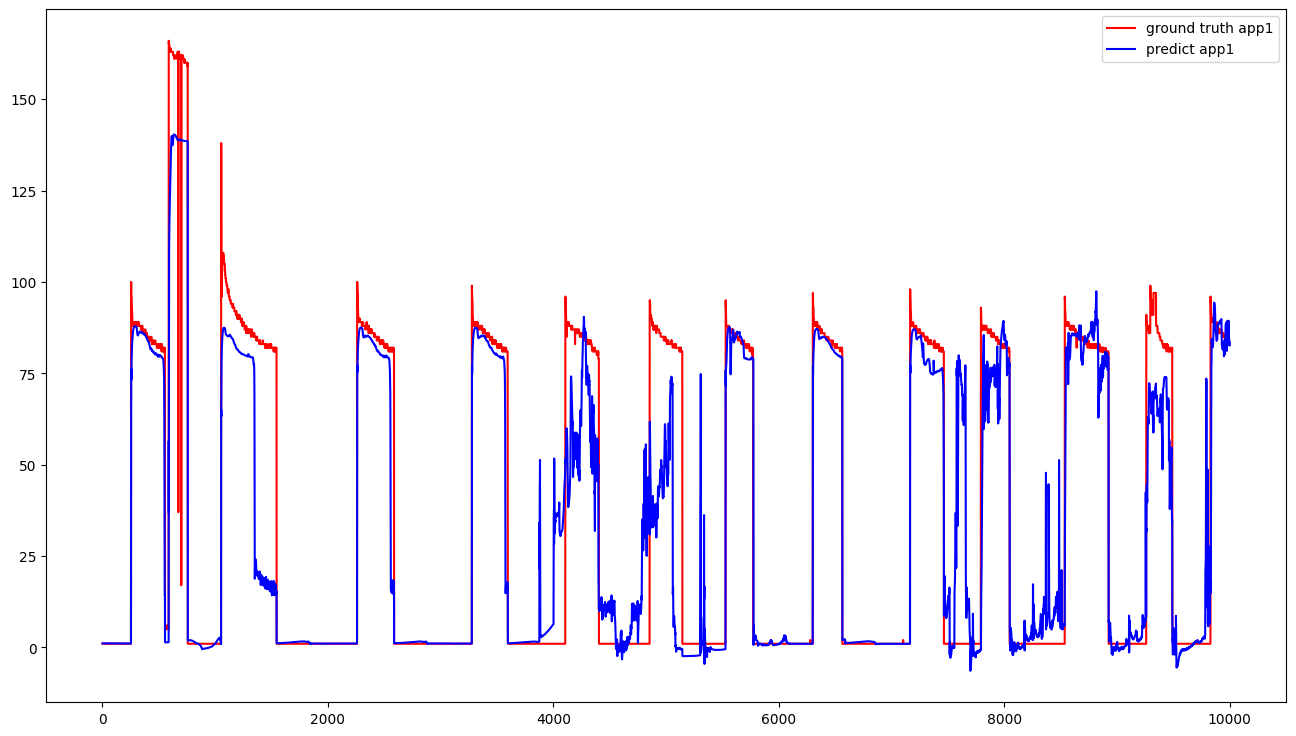

In [87]:
plt.figure(figsize = (16,9))
plt.plot(ground_truth.reshape(-1)[10000:20000], color = 'r', label = 'ground truth app1')
plt.plot(pred.reshape(-1)[10000:20000], color = 'b', label = 'predict app1')
plt.legend(loc = 'best')
plt.show()

In [88]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)
def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)
def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)
def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

In [89]:
F1_energy_based_fixed(pred, ground_truth)

array([0.7983237], dtype=float32)

In [90]:
NEP_fixed(pred, ground_truth)

array([0.39931652], dtype=float32)